<a href="https://colab.research.google.com/github/fayashi06/Deep-Learning-Classification-/blob/main/academic_paper_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [17]:
!unzip /content/ai4i+2020+predictive+maintenance+dataset.zip

Archive:  /content/ai4i+2020+predictive+maintenance+dataset.zip
 extracting: ai4i2020.csv            


In [18]:
df = pd.read_csv('/content/ai4i2020.csv')

In [19]:
df

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,M24855,M,298.8,308.4,1604,29.5,14,0,0,0,0,0,0
9996,9997,H39410,H,298.9,308.4,1632,31.8,17,0,0,0,0,0,0
9997,9998,M24857,M,299.0,308.6,1645,33.4,22,0,0,0,0,0,0
9998,9999,H39412,H,299.0,308.7,1408,48.5,25,0,0,0,0,0,0


In [20]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [21]:
df = df.drop(['UDI', 'Product ID'], axis=1)

In [22]:
df

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,M,298.8,308.4,1604,29.5,14,0,0,0,0,0,0
9996,H,298.9,308.4,1632,31.8,17,0,0,0,0,0,0
9997,M,299.0,308.6,1645,33.4,22,0,0,0,0,0,0
9998,H,299.0,308.7,1408,48.5,25,0,0,0,0,0,0


In [23]:
df['Type'] = LabelEncoder().fit_transform(df['Type'])

In [24]:
df

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,2,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,1,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,1,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,1,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,1,298.2,308.7,1408,40.0,9,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,2,298.8,308.4,1604,29.5,14,0,0,0,0,0,0
9996,0,298.9,308.4,1632,31.8,17,0,0,0,0,0,0
9997,2,299.0,308.6,1645,33.4,22,0,0,0,0,0,0
9998,0,299.0,308.7,1408,48.5,25,0,0,0,0,0,0


In [25]:
X = df.drop('Machine failure', axis=1)

In [26]:
y = df['Machine failure'].copy()


In [27]:
df

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,2,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,1,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,1,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,1,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,1,298.2,308.7,1408,40.0,9,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,2,298.8,308.4,1604,29.5,14,0,0,0,0,0,0
9996,0,298.9,308.4,1632,31.8,17,0,0,0,0,0,0
9997,2,299.0,308.6,1645,33.4,22,0,0,0,0,0,0
9998,0,299.0,308.7,1408,48.5,25,0,0,0,0,0,0


In [28]:
print(df.isnull().sum())

Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64


In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [30]:
X_train.shape

(8000, 11)

In [31]:
X_test.shape

(2000, 11)

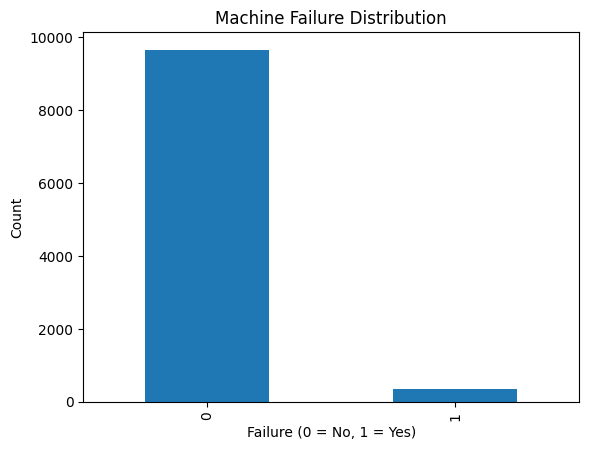

In [32]:
plt.figure()
df['Machine failure'].value_counts().plot(kind='bar')
plt.title("Machine Failure Distribution")
plt.xlabel("Failure (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

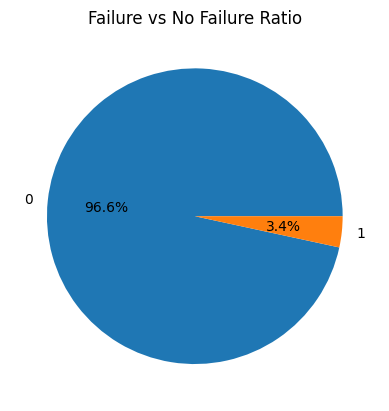

In [33]:
plt.figure()
df['Machine failure'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Failure vs No Failure Ratio")
plt.ylabel("")
plt.show()

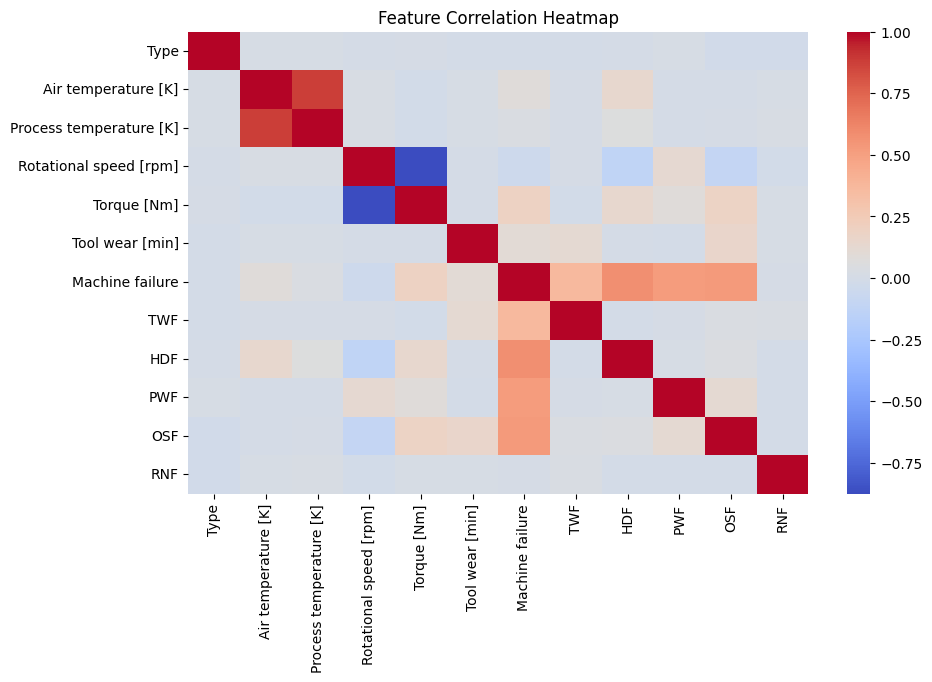

In [34]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), cmap='coolwarm', annot=False)
plt.title("Feature Correlation Heatmap")
plt.show()

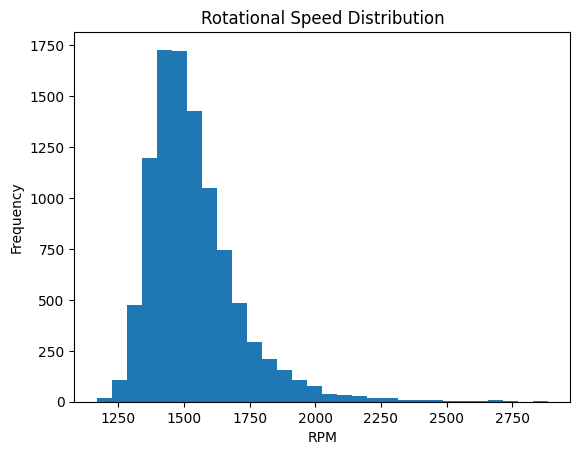

In [35]:
plt.figure()
plt.hist(df['Rotational speed [rpm]'], bins=30)
plt.title("Rotational Speed Distribution")
plt.xlabel("RPM")
plt.ylabel("Frequency")
plt.show()

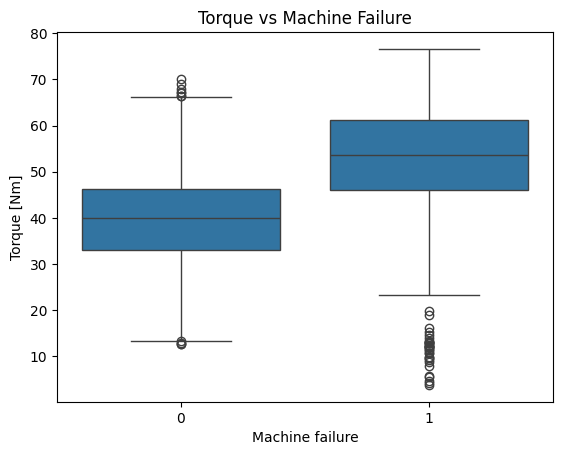

In [36]:
plt.figure()
sns.boxplot(x='Machine failure', y='Torque [Nm]', data=df)
plt.title("Torque vs Machine Failure")
plt.show()

In [37]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

In [38]:
num_feature = X_train.select_dtypes(include = np.number).columns
cat_feature = X_train.select_dtypes(exclude = np.number).columns

In [39]:


cat_feature

Index([], dtype='object')

In [40]:
num_feature

Index(['Type', 'Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'TWF',
       'HDF', 'PWF', 'OSF', 'RNF'],
      dtype='object')

In [41]:
from sklearn.preprocessing import StandardScaler

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_feature),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_feature)
])

model = Pipeline([
    ('preprocessor', preprocessor),
    ('svm', SVC(kernel='rbf', class_weight='balanced', probability=True))
])

In [42]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['Type', 'Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'TWF',
       'HDF', 'PWF', 'OSF', 'RNF'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index([], dtype='object'))])),
                ('svm', SVC(class_weight='balanced', probability=True))])

In [43]:
probability=True

In [44]:
('svm', SVC(kernel='rbf', C=1.0, gamma='scale',
            class_weight='balanced',
            probability=True))

('svm', SVC(class_weight='balanced', probability=True))

In [45]:
from sklearn.metrics import roc_curve, roc_auc_score

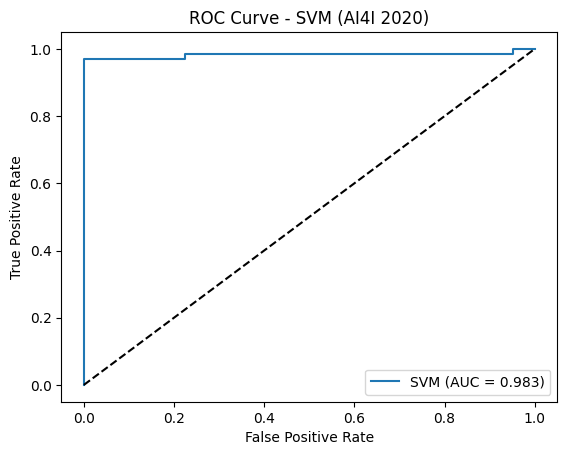

In [46]:
y_proba = model.predict_proba(X_test)[:, 1]


fpr, tpr, thresholds = roc_curve(y_test, y_proba)


auc_score = roc_auc_score(y_test, y_proba)

plt.figure()
plt.plot(fpr, tpr, label=f"SVM (AUC = {auc_score:.3f})")
plt.plot([0, 1], [0, 1], 'k--')  # random classifier line

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - SVM (AI4I 2020)")
plt.legend()
plt.show()

In [47]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [48]:
model.score(X_train, y_train)

0.999125

In [49]:
model.score(X_test, y_test)

0.999

In [50]:
y_pred = model.predict(X_test)
f1_score_value = f1_score(y_test, y_pred)
f1_score_value

0.9850746268656716

In [51]:
precision = precision_score(y_test, y_pred)
precision

1.0

In [52]:
recall = recall_score(y_test, y_pred)
recall

0.9705882352941176

In [53]:
accuraccy = accuracy_score(y_test, y_pred)
accuraccy

0.999

In [54]:
y_pred

array([0, 0, 0, ..., 0, 0, 0])

In [55]:
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


Confusion Matrix:
 [[1932    0]
 [   2   66]]


In [56]:
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1932
           1       1.00      0.97      0.99        68

    accuracy                           1.00      2000
   macro avg       1.00      0.99      0.99      2000
weighted avg       1.00      1.00      1.00      2000



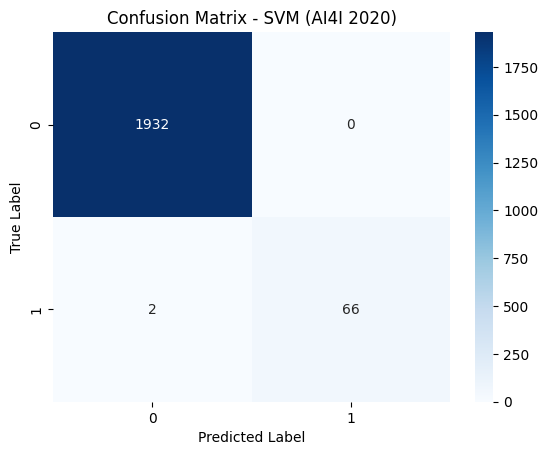

In [57]:
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - SVM (AI4I 2020)")
plt.show()

In [58]:
report_dict = classification_report(
    y_test, y_pred,
    target_names=["Non-Fault (0)", "Fault (1)"],
    output_dict=True
)

df_report = pd.DataFrame(report_dict).transpose()
print(df_report)

               precision    recall  f1-score   support
Non-Fault (0)   0.998966  1.000000  0.999483  1932.000
Fault (1)       1.000000  0.970588  0.985075    68.000
accuracy        0.999000  0.999000  0.999000     0.999
macro avg       0.999483  0.985294  0.992279  2000.000
weighted avg    0.999001  0.999000  0.998993  2000.000


In [59]:
#model 2000 dene test datasindan cemi 2sini sehv predict etmishdir

In [60]:
#Random Forest model

In [61]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42,
    stratify = y
)

In [62]:
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy = 'median')),
])
transformer = ColumnTransformer([
    ('num', num_pipeline, num_feature),
])
full_pipeline = Pipeline([
    ('transformer', transformer),
    ('model', RandomForestClassifier(
        n_estimators = 100,
        max_depth = 10,
        random_state = 42,))
])
full_pipeline.fit(X_train, y_train)

Pipeline(steps=[('transformer',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  Index(['Type', 'Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'TWF',
       'HDF', 'PWF', 'OSF', 'RNF'],
      dtype='object'))])),
                ('model',
                 RandomForestClassifier(max_depth=10, random_state=42))])

In [63]:
full_pipeline.score(X_test, y_test)

0.999

In [64]:
full_pipeline.score(X_train, y_train)

0.999125

In [65]:
y_pred = full_pipeline.predict(X_test)
confusion_matrix(y_test,y_pred)

array([[1932,    0],
       [   2,   66]])

In [66]:
feature_importance = full_pipeline.named_steps['model'].feature_importances_
feature_names = full_pipeline.named_steps['transformer'].get_feature_names_out()
importance_df = pd.DataFrame({'feature': feature_names, 'importance': feature_importance}).sort_values(by= 'importance', ascending=False)
importance_df

,feature,importance
7,num__HDF,0.276747
9,num__OSF,0.234545
8,num__PWF,0.197401
6,num__TWF,0.112189
4,num__Torque [Nm],0.078976
3,num__Rotational speed [rpm],0.044768
5,num__Tool wear [min],0.026591
1,num__Air temperature [K],0.014214
2,num__Process temperature [K],0.011132
0,num__Type,0.002963


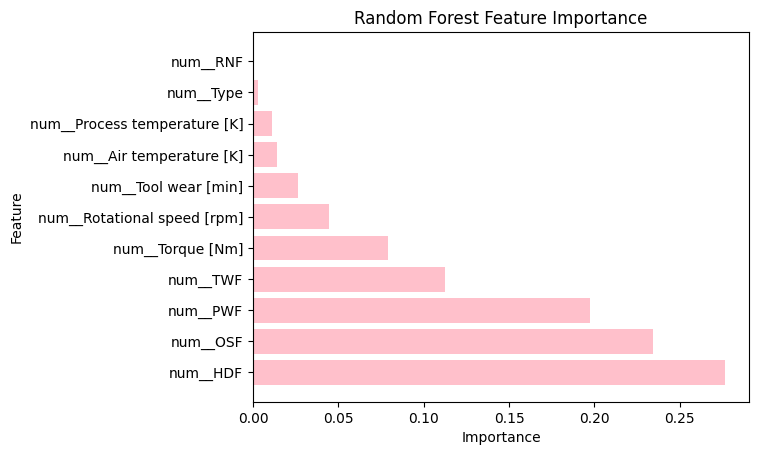

In [67]:
plt.barh(importance_df['feature'], importance_df['importance'], color = 'pink')
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

In [78]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Reshape Data for Proper Tabular-LSTM Sequence Alignment
# Instead of long sliding windows, we feed features as a direct sequence step of 1
X_train_lstm = np.expand_dims(X_train, axis=1) # Shape becomes: [Samples, 1, Features]
X_test_lstm = np.expand_dims(X_test, axis=1)

X_train_t = torch.tensor(X_train_lstm, dtype=torch.float32)
y_train_t = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1) # Fix: convert Series to numpy array
X_test_t = torch.tensor(X_test_lstm, dtype=torch.float32)
y_test_t = torch.tensor(y_test.values, dtype=torch.float32).unsqueeze(1) # Fix: convert Series to numpy array

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=64, shuffle=False)

# 2. Advanced High-Capacity LSTM Architecture
class AdvancedPumpLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, num_layers=2):
        super(AdvancedPumpLSTM, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        # Bidirectional LSTM to capture deep coordinate intersections
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True,
                            dropout=0.3, bidirectional=True)

        # Hidden dim is multiplied by 2 due to bidirectionality
        self.bn = nn.BatchNorm1d(hidden_dim * 2)
        self.fc1 = nn.Linear(hidden_dim * 2, 32)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(32, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :] # Extract the final sequence representation
        out = self.bn(out)   # Normalize features before dense layers
        out = self.fc1(out)
        out = self.relu(out)
        out = self.dropout(out)
        logits = self.fc2(out)
        return logits

# 3. Custom Focal Loss to Replace Unstable Weighting
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        # Computes loss using raw logits for numerical stability
        BCE_loss = F.binary_cross_entropy_with_logits(inputs, targets, reduction='none')
        pt = torch.exp(-BCE_loss) # Finds probability of correct class
        F_loss = self.alpha * (1 - pt)**self.gamma * BCE_loss

        if self.reduction == 'mean':
            return torch.mean(F_loss)
        return torch.sum(F_loss)

# Initialize system pipeline
INPUT_FEATURES = X_train_lstm.shape[2]
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = AdvancedPumpLSTM(input_dim=INPUT_FEATURES).to(device)

criterion = FocalLoss(alpha=0.75, gamma=2.0) # Alpha balanced toward the rare faults
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0005, weight_decay=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

# 4. Training Execution
model.train()
for epoch in range(35):
    epoch_loss = 0
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)

        optimizer.zero_grad()
        logits = model(batch_X)
        loss = criterion(logits, batch_y)
        loss.backward()

        nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)
        optimizer.step()
        epoch_loss += loss.item()

    current_lr = optimizer.param_groups[0]['lr']
    scheduler.step(epoch_loss)
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/35 | Focal Loss: {epoch_loss/len(train_loader):.4f} | LR: {current_lr}")

# 5. Model Evaluation
model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)
        logits = model(batch_X)
        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).cpu().numpy().astype(int)

        all_preds.extend(preds)
        all_targets.extend(batch_y.numpy().astype(int))

print("\n--- Corrected & Optimized PyTorch LSTM Performance ---")
print(classification_report(all_targets, all_preds, digits=4))

Epoch 5/35 | Focal Loss: 0.0363 | LR: 0.0005
Epoch 10/35 | Focal Loss: 0.0299 | LR: 0.00025
Epoch 15/35 | Focal Loss: 0.0301 | LR: 0.00025
Epoch 20/35 | Focal Loss: 0.0302 | LR: 0.000125
Epoch 25/35 | Focal Loss: 0.0289 | LR: 6.25e-05
Epoch 30/35 | Focal Loss: 0.0261 | LR: 3.125e-05
Epoch 35/35 | Focal Loss: 0.0269 | LR: 1.5625e-05

--- Corrected & Optimized PyTorch LSTM Performance ---
              precision    recall  f1-score   support

           0     0.9770    0.9907    0.9838      1932
           1     0.5610    0.3382    0.4220        68

    accuracy                         0.9685      2000
   macro avg     0.7690    0.6645    0.7029      2000
weighted avg     0.9629    0.9685    0.9647      2000

